In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm
import os
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

print("✅ 所有库导入成功")
print(f"PyTorch版本: {torch.__version__}")

✅ 所有库导入成功
PyTorch版本: 2.12.0+cpu


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("使用CPU训练，会慢一些")

使用设备: cpu
使用CPU训练，会慢一些


In [3]:
# 定义预处理
transform_train = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((48, 48)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

transform_test = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

print("✅ 预处理设置完成")

✅ 预处理设置完成


In [10]:
# 修复中文字体显示问题
import matplotlib.pyplot as plt

# 设置matplotlib支持中文
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

print("✅ 字体设置完成")
print("重新运行显示图片的格子即可正常显示中文")

✅ 字体设置完成
重新运行显示图片的格子即可正常显示中文


正在加载数据...

✅ 数据加载成功！
训练集: 28709 张图片
测试集: 3589 张图片

数据加载器创建成功:
训练批次数: 449
测试批次数: 57

表情类别: ['生气', '厌恶', '恐惧', '开心', '难过', '惊讶', '中性']


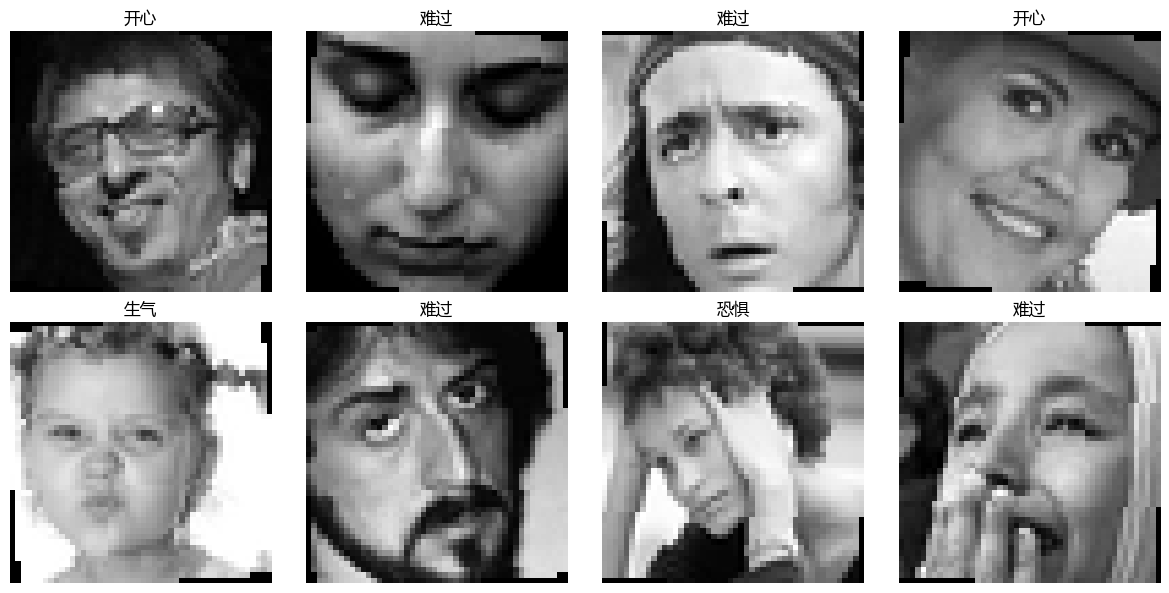


✅ 示例图片已保存到 data_samples.png


In [12]:
import torch
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from PIL import Image
import os
import matplotlib.pyplot as plt

# 数据预处理
transform_train = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((48, 48)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

transform_test = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# 自定义数据集类
class FER2013Dataset(Dataset):
    def __init__(self, csv_path, split='Training', transform=None):
        self.data = pd.read_csv(csv_path)
        self.data = self.data[self.data.Usage == split]
        self.transform = transform
        self.split = split
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        # 将像素字符串转为数组（48x48）
        pixels = np.array(row['pixels'].split(' '), dtype=np.float32)
        pixels = pixels.reshape(48, 48)
        label = row['emotion']
        
        # 转为PIL图像
        img = Image.fromarray(pixels).convert('L')
        
        if self.transform:
            img = self.transform(img)
        
        return img, label

# 加载数据
csv_path = './data/fer2013/fer2013.csv'
print("正在加载数据...")

train_dataset = FER2013Dataset(csv_path, split='Training', transform=transform_train)
test_dataset = FER2013Dataset(csv_path, split='PublicTest', transform=transform_test)

print(f"\n✅ 数据加载成功！")
print(f"训练集: {len(train_dataset)} 张图片")
print(f"测试集: {len(test_dataset)} 张图片")

# 创建数据加载器
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"\n数据加载器创建成功:")
print(f"训练批次数: {len(train_loader)}")
print(f"测试批次数: {len(test_loader)}")

# 表情类别
emotions = ['生气', '厌恶', '恐惧', '开心', '难过', '惊讶', '中性']
print(f"\n表情类别: {emotions}")

# 显示几张示例图片
images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i in range(8):
    row, col = i // 4, i % 4
    img = images[i].squeeze().numpy()
    img = (img + 1) / 2  # 反归一化
    axes[row, col].imshow(img, cmap='gray')
    axes[row, col].set_title(emotions[labels[i]])
    axes[row, col].axis('off')
plt.tight_layout()
plt.savefig("data_samples.png")
plt.show()
print("\n✅ 示例图片已保存到 data_samples.png")

In [13]:
# 检查GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")
if device.type == "cuda":
    print(f"GPU型号: {torch.cuda.get_device_name(0)}")
else:
    print("使用CPU训练，会慢一些（预计30-40分钟）")

使用设备: cpu
使用CPU训练，会慢一些（预计30-40分钟）


In [14]:
# 定义CNN模型
import torch.nn as nn

class EmotionCNN(nn.Module):
    def __init__(self, num_classes=7):
        super(EmotionCNN, self).__init__()
        
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(128 * 6 * 6, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

model = EmotionCNN().to(device)
print(model)
print(f"\n参数量: {sum(p.numel() for p in model.parameters()):,}")

EmotionCNN(
  (conv1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Dropout(p=0.3, inplace=False)
    (1): Linear(in_fea

In [15]:
# 损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

print("损失函数: CrossEntropyLoss")
print("优化器: Adam (lr=0.001)")
print("学习率调度: StepLR (每10轮衰减0.5)")

损失函数: CrossEntropyLoss
优化器: Adam (lr=0.001)
学习率调度: StepLR (每10轮衰减0.5)


In [16]:
# 训练函数
from tqdm import tqdm

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for images, labels in tqdm(loader, desc="训练"):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    return total_loss / len(loader), 100. * correct / total

# 测试函数
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="测试"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    return total_loss / len(loader), 100. * correct / total

# 训练循环
num_epochs = 30
train_losses, train_accs = [], []
test_losses, test_accs = [], []
best_acc = 0

print("开始训练...")
print("=" * 50)

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_losses.append(test_loss)
    test_accs.append(test_acc)
    
    scheduler.step()
    
    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), "emotion_model.pth")
        print(f"✅ 保存最佳模型 (准确率: {test_acc:.2f}%)")
    
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print(f"  训练 Loss: {train_loss:.4f} | 准确率: {train_acc:.2f}%")
    print(f"  测试 Loss: {test_loss:.4f} | 准确率: {test_acc:.2f}%")
    print("-" * 40)

print("=" * 50)
print(f"🏆 训练完成！最佳测试准确率: {best_acc:.2f}%")

开始训练...


测试: 100%|████████████████████████████████████████████████████████████████████████████| 57/57 [00:05<00:00, 10.11it/s]


✅ 保存最佳模型 (准确率: 37.06%)

Epoch 1/30
  训练 Loss: 1.7468 | 准确率: 29.72%
  测试 Loss: 1.6127 | 准确率: 37.06%
----------------------------------------


测试: 100%|████████████████████████████████████████████████████████████████████████████| 57/57 [00:04<00:00, 12.48it/s]


✅ 保存最佳模型 (准确率: 45.64%)

Epoch 2/30
  训练 Loss: 1.5125 | 准确率: 40.59%
  测试 Loss: 1.4162 | 准确率: 45.64%
----------------------------------------


...

✅ 保存最佳模型 (准确率: 59.79%)

Epoch 28/30
  训练 Loss: 1.0787 | 准确率: 58.89%
  测试 Loss: 1.0520 | 准确率: 59.79%
----------------------------------------


测试: 100%|████████████████████████████████████████████████████████████████████████████| 57/57 [00:05<00:00, 10.90it/s]


✅ 保存最佳模型 (准确率: 60.32%)

Epoch 29/30
  训练 Loss: 1.0787 | 准确率: 58.94%
  测试 Loss: 1.0470 | 准确率: 60.32%
----------------------------------------


测试: 100%|████████████████████████████████████████████████████████████████████████████| 57/57 [00:04<00:00, 13.82it/s]


Epoch 30/30
  训练 Loss: 1.0749 | 准确率: 58.79%
  测试 Loss: 1.0527 | 准确率: 59.96%
----------------------------------------
🏆 训练完成！最佳测试准确率: 60.32%


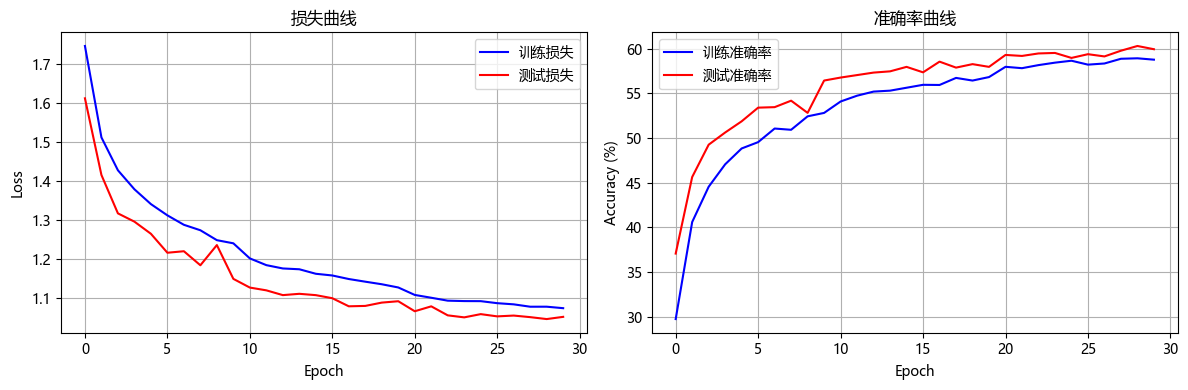

✅ 训练曲线已保存到 loss_curve.png


In [17]:
# 绘制训练曲线
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 损失曲线
axes[0].plot(train_losses, label='训练损失', color='blue')
axes[0].plot(test_losses, label='测试损失', color='red')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('损失曲线')
axes[0].legend()
axes[0].grid(True)

# 准确率曲线
axes[1].plot(train_accs, label='训练准确率', color='blue')
axes[1].plot(test_accs, label='测试准确率', color='red')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('准确率曲线')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("loss_curve.png", dpi=150)
plt.show()
print("✅ 训练曲线已保存到 loss_curve.png")

In [20]:
# 测试单张图片
from PIL import Image

def predict_emotion(image_path):
    # 加载并预处理图片
    img = Image.open(image_path).convert('L')
    img = img.resize((48, 48))
    
    # 转为tensor
    from torchvision import transforms
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    img_tensor = transform(img).unsqueeze(0).to(device)
    
    # 预测
    model.eval()
    with torch.no_grad():
        output = model(img_tensor)
        probs = torch.softmax(output, dim=1)
        pred = torch.argmax(probs, dim=1).item()
        confidence = probs[0][pred].item()
    
    emotions = ['生气', '厌恶', '恐惧', '开心', '难过', '惊讶', '中性']
    print(f"预测结果: {emotions[pred]}")
    print(f"置信度: {confidence:.2%}")
    
    # 显示所有类别概率
    print("\n所有表情概率:")
    for i, (emotion, prob) in enumerate(zip(emotions, probs[0])):
        bar = "█" * int(prob * 30)
        print(f"  {emotion}: {bar} {prob:.2%}")

# 测试
predict_emotion("D:/哭.jpg")

预测结果: 难过
置信度: 50.06%

所有表情概率:
  生气: ██ 7.17%
  厌恶:  0.06%
  恐惧: ██ 7.57%
  开心: █████ 17.14%
  难过: ███████████████ 50.06%
  惊讶:  0.17%
  中性: █████ 17.84%
